# Assignment 6 — AI-Based Image Style Transfer

### Objective
This notebook compares two different deep-learning approaches for transforming the appearance of the same photograph:

1. **CycleGAN** — photo-to-artistic-domain translation using a pretrained model.
2. **VGG19 Neural Style Transfer** — preservation of image content while applying the visual characteristics of a separate artwork.



## 1. Environment Setup

The experiment uses PyTorch, TorchVision, Pillow, Matplotlib, and the official PyTorch implementation of CycleGAN.


In [1]:
# Install the libraries needed for the experiment.
!pip -q install torch torchvision pillow requests

import os
import sys
import copy
import urllib.request
from io import BytesIO

import numpy as np
import requests
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as tv_models

print("PyTorch:", torch.__version__)
print("TorchVision:", __import__("torchvision").__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


PyTorch: 2.11.0+cu130
TorchVision: 0.26.0+cu130
Device: cuda


## 2. Select and Prepare the Original Image

A landscape photograph is used as the content image for both methods. Keeping the same image for both experiments makes the comparison fair.


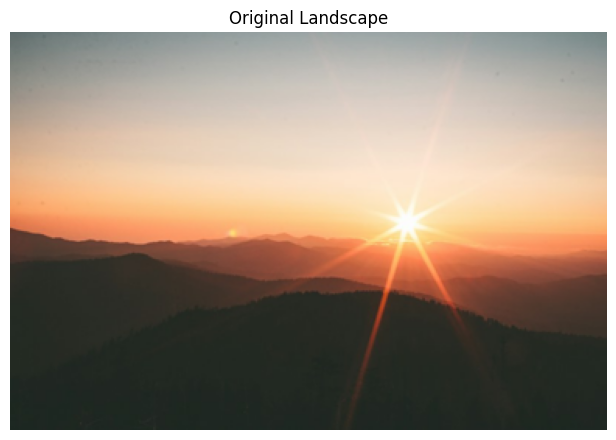

Original image size: (384, 256)


In [2]:
# Download a landscape photograph.
photo_url = "https://images.unsplash.com/photo-1500534623283-312aade485b7?w=800"

reply = requests.get(photo_url, timeout=30)
reply.raise_for_status()

content_img = Image.open(BytesIO(reply.content)).convert("RGB")

# Keep a moderate size so that the neural style-transfer optimization is practical.
content_img = content_img.resize((384, 256))

content_img.save("original_landscape.jpg")

plt.figure(figsize=(7, 4.5))
plt.imshow(content_img)
plt.title("Original Landscape")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Original image size:", content_img.size)


## 3. Method 1 — CycleGAN

CycleGAN performs **domain translation**. Instead of simply adding a filter, the pretrained network has learned how images in one visual domain can be transformed into another.

For this experiment, the pretrained **photo-to-Monet** CycleGAN model is used.

### Cycle consistency
CycleGAN uses a cycle-consistency constraint: an image translated from domain A to domain B and then back to A should remain close to the original. This encourages the transformation to change the domain while retaining meaningful image content.


In [3]:
# Obtain the official CycleGAN implementation.
if not os.path.exists("/content/pytorch-CycleGAN-and-pix2pix"):
    !git clone -q https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

%cd /content/pytorch-CycleGAN-and-pix2pix
!pip -q install dominate visdom


/content/pytorch-CycleGAN-and-pix2pix
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 30.9 MB/s eta 0:00:00


In [5]:
from models.networks import define_G

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = define_G(
    input_nc=3,
    output_nc=3,
    ngf=64,
    netG="resnet_9blocks",
    norm="instance",
    use_dropout=False,
    init_type="normal",
    init_gain=0.02
)

checkpoint_file = (
    "/content/pytorch-CycleGAN-and-pix2pix/"
    "checkpoints/style_monet_pretrained/latest_net_G.pth"
)

state = torch.load(checkpoint_file, map_location="cpu")

generator.load_state_dict(state, strict=False)
generator = generator.to(device).eval()

print("Pretrained CycleGAN generator is ready.")


Pretrained CycleGAN generator is ready.


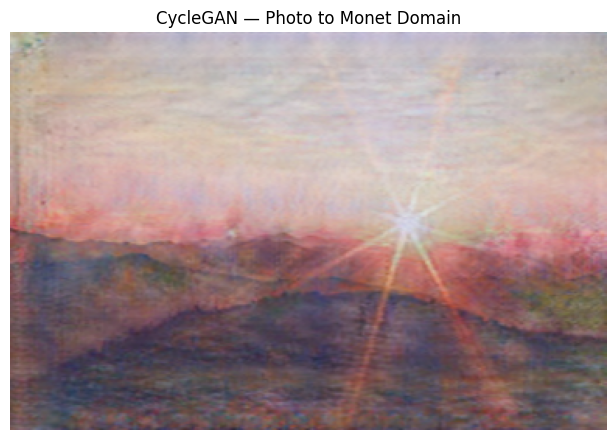

In [6]:
# Prepare the photograph in the format expected by CycleGAN.
gan_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

gan_input = gan_transform(content_img).unsqueeze(0).to(device)

with torch.inference_mode():
    gan_result = generator(gan_input)

# Convert from [-1, 1] back to ordinary RGB values.
gan_result = gan_result[0].cpu() * 0.5 + 0.5
gan_result = gan_result.clamp(0, 1)

cycle_output = T.ToPILImage()(gan_result)
cycle_output = cycle_output.resize(content_img.size)
cycle_output.save("cyclegan_monet_output.jpg")

plt.figure(figsize=(7, 4.5))
plt.imshow(cycle_output)
plt.title("CycleGAN — Photo to Monet Domain")
plt.axis("off")
plt.tight_layout()
plt.show()


## 4. Method 2 — VGG19 Neural Style Transfer

Neural Style Transfer uses two inputs:

- **Content image:** the original landscape photograph.
- **Style image:** an artwork.

A pretrained VGG19 network extracts visual features. The optimization then adjusts a target image so that it remains close to the content representation while its texture statistics resemble the artwork.


In [7]:
# Load the pretrained VGG19 feature extractor.
vgg_weights = tv_models.VGG19_Weights.DEFAULT
vgg = tv_models.vgg19(weights=vgg_weights).features.to(device).eval()

for parameter in vgg.parameters():
    parameter.requires_grad_(False)

print("VGG19 feature extractor loaded.")


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 76.4MB/s]


VGG19 feature extractor loaded.


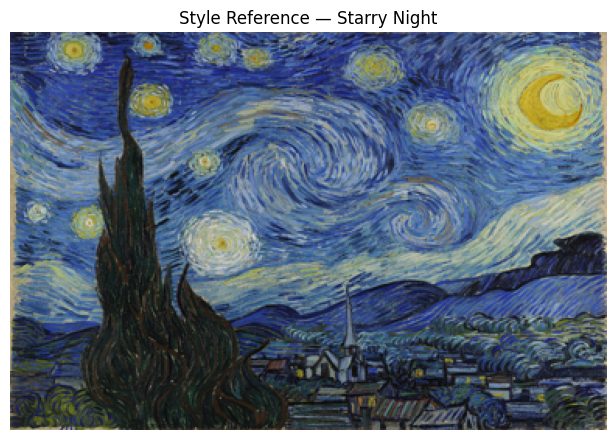

In [8]:
# Download a different artistic style image from a public GitHub repository.
style_url = (
    "https://raw.githubusercontent.com/leongatys/"
    "PytorchNeuralStyleTransfer/master/Images/vangogh_starry_night.jpg"
)

urllib.request.urlretrieve(style_url, "style_reference.jpg")

style_img = Image.open("style_reference.jpg").convert("RGB")
style_img = style_img.resize(content_img.size)

plt.figure(figsize=(7, 4.5))
plt.imshow(style_img)
plt.title("Style Reference — Starry Night")
plt.axis("off")
plt.tight_layout()
plt.show()


## 5. Extract Content and Style Features

The VGG19 feature maps are used at several layers.

- A deeper feature representation is used for **content**.
- Several earlier and middle layers are used for **style**.
- Gram matrices summarize correlations between feature channels and are used to represent style.


In [9]:
# VGG normalization expected by the pretrained network.
vgg_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
vgg_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def prepare_image(pil_img):
    tensor = T.ToTensor()(pil_img).unsqueeze(0).to(device)
    return (tensor - vgg_mean) / vgg_std

def extract_features(x):
    wanted = {
        0: "conv1_1",
        5: "conv2_1",
        10: "conv3_1",
        19: "conv4_1",
        21: "conv4_2",
        28: "conv5_1",
    }
    features = {}
    for index, layer in enumerate(vgg):
        x = layer(x)
        if index in wanted:
            features[wanted[index]] = x
    return features

def gram_matrix(feature_map):
    _, channels, height, width = feature_map.shape
    values = feature_map.reshape(channels, height * width)
    return values @ values.t()

content_tensor = prepare_image(content_img)
style_tensor = prepare_image(style_img)

with torch.no_grad():
    content_feats = extract_features(content_tensor)
    style_feats = extract_features(style_tensor)

style_targets = {
    name: gram_matrix(style_feats[name])
    for name in ["conv1_1", "conv2_1", "conv3_1", "conv4_1", "conv5_1"]
}

print("Content and style feature representations created.")


Content and style feature representations created.


## 6. Optimize the Stylized Image

The target starts as a copy of the content image.

At each iteration:

1. Extract VGG19 features from the target.
2. Calculate **content loss**.
3. Calculate **style loss** using Gram matrices.
4. Combine the losses.
5. Update the target pixels with Adam.

A smaller number of iterations is used here to keep the notebook practical in Colab.


In [10]:
# Start from the original photograph instead of random noise.
target = content_tensor.clone().detach().requires_grad_(True)

content_weight = 1.0
style_weight = 8e5

style_layer_weights = {
    "conv1_1": 1.0,
    "conv2_1": 0.75,
    "conv3_1": 0.35,
    "conv4_1": 0.20,
    "conv5_1": 0.10,
}

optimizer = optim.Adam([target], lr=0.003)
iterations = 200

print("Beginning style-transfer optimization...")

for iteration in range(1, iterations + 1):
    current = extract_features(target)

    content_loss = torch.mean(
        (current["conv4_2"] - content_feats["conv4_2"]) ** 2
    )

    style_loss = 0.0
    for layer_name, layer_weight in style_layer_weights.items():
        current_gram = gram_matrix(current[layer_name])
        reference_gram = style_targets[layer_name]
        style_loss += layer_weight * torch.mean(
            (current_gram - reference_gram) ** 2
        )

    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if iteration % 40 == 0:
        print(
            f"Iteration {iteration:03d}/{iterations} | "
            f"Total: {total_loss.item():.3f} | "
            f"Content: {content_loss.item():.5f} | "
            f"Style: {style_loss.item():.5f}"
        )


Beginning style-transfer optimization...
Iteration 040/200 | Total: 614699813044224.000 | Content: 4.81089 | Style: 768374784.00000
Iteration 080/200 | Total: 404587093688320.000 | Content: 5.97608 | Style: 505733888.00000
Iteration 120/200 | Total: 302159539208192.000 | Content: 6.19423 | Style: 377699424.00000
Iteration 160/200 | Total: 234895418851328.000 | Content: 6.35856 | Style: 293619264.00000
Iteration 200/200 | Total: 183463302922240.000 | Content: 6.52793 | Style: 229329136.00000


## 7. Convert and Display the Neural Style Transfer Result


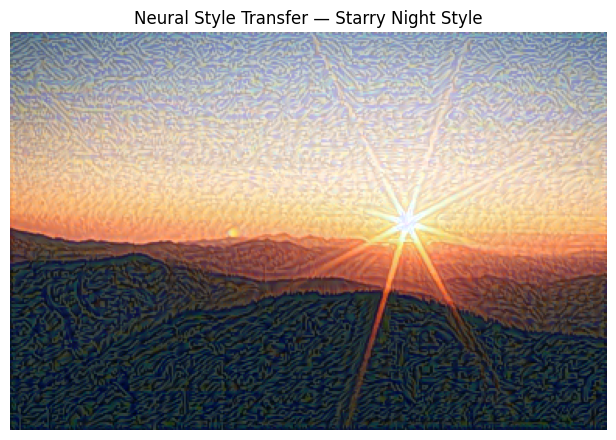

In [11]:
def denormalize_image(x):
    result = x.detach().cpu().squeeze(0)
    result = result * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    result = result + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    result = result.clamp(0, 1)
    return result.permute(1, 2, 0).numpy()

nst_array = denormalize_image(target)
nst_image = Image.fromarray((nst_array * 255).astype(np.uint8))
nst_image = nst_image.resize(content_img.size)
nst_image.save("neural_style_output.jpg")

plt.figure(figsize=(7, 4.5))
plt.imshow(nst_image)
plt.title("Neural Style Transfer — Starry Night Style")
plt.axis("off")
plt.tight_layout()
plt.show()


## 8. Final Side-by-Side Comparison


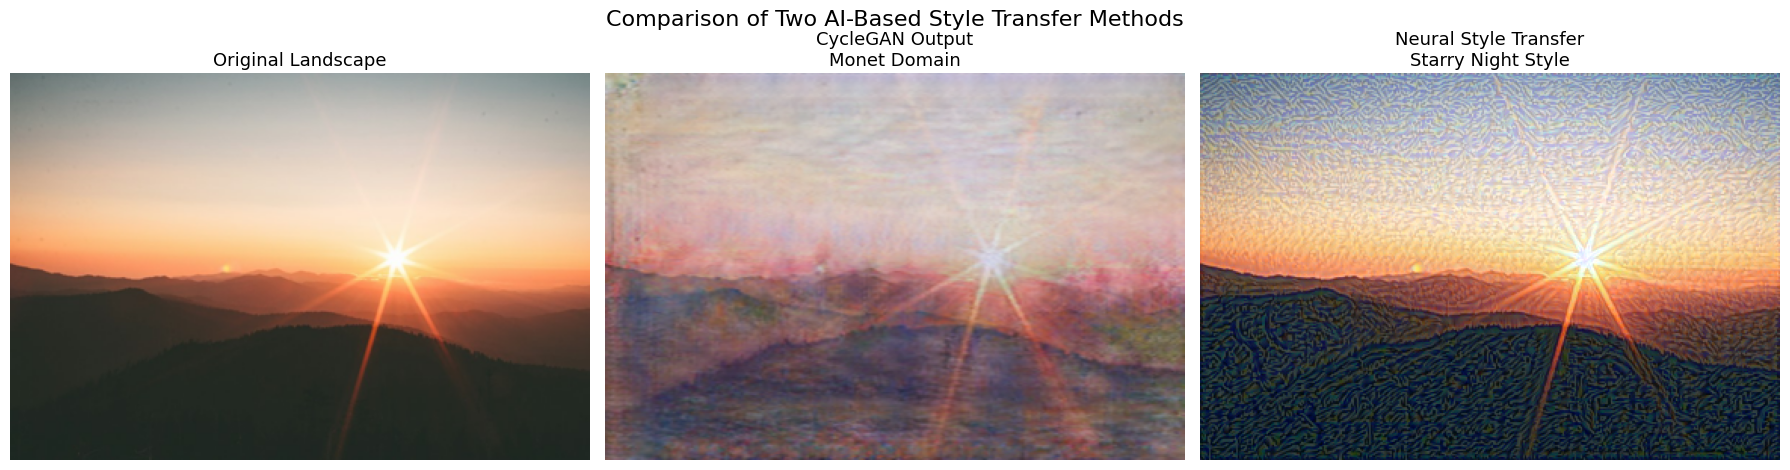

Final comparison saved as assignment6_comparison.jpg


In [12]:
fig, panels = plt.subplots(1, 3, figsize=(18, 5))

panels[0].imshow(content_img)
panels[0].set_title("Original Landscape", fontsize=13)
panels[0].axis("off")

panels[1].imshow(cycle_output)
panels[1].set_title("CycleGAN Output\nMonet Domain", fontsize=13)
panels[1].axis("off")

panels[2].imshow(nst_image)
panels[2].set_title("Neural Style Transfer\nStarry Night Style", fontsize=13)
panels[2].axis("off")

fig.suptitle("Comparison of Two AI-Based Style Transfer Methods", fontsize=16)
plt.tight_layout()
plt.savefig("assignment6_comparison.jpg", dpi=180, bbox_inches="tight")
plt.show()

print("Final comparison saved as assignment6_comparison.jpg")


## Written Comparison

**Content preservation:** The Neural Style Transfer result generally keeps the original landscape structure more directly because its content loss explicitly encourages the generated image to remain close to the content representation. CycleGAN also retains major scene information, but its domain-translation objective can change colours, textures, and local appearance more strongly.

**Style transformation:** CycleGAN produces a broad photo-to-artistic-domain transformation because the pretrained generator has learned characteristics of the Monet domain. Neural Style Transfer applies the visual statistics of the selected artwork, so its result is usually recognizable as the same photograph with an added artistic texture.

**Main difference:** CycleGAN learns a mapping between two image domains, while Neural Style Transfer optimizes an image using content features and style features extracted by VGG19. CycleGAN also uses cycle consistency during training, whereas the VGG-based method uses content and style losses during optimization.


## Conclusion

The experiment shows that two AI methods can modify the same photograph in different ways. CycleGAN is designed for domain-level image translation, while VGG19 Neural Style Transfer is designed to combine the content of one image with the visual style of another. Comparing the three final images makes the difference between domain translation and artistic style transfer easier to observe.
